In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [43]:
# To read datas
df=pd.read_csv("ds.csv",
               encoding="latin-1",
               engine="python",
               on_bad_lines="skip")
df

,phrase,sentiment
0,"""I love spending time with my family.""",positive
1,"""Sunshine always brightens my day.""",positive
2,"""Helping others is so rewarding.""",positive
3,"""A good book can transport you to another world.""",positive
4,"""The smell of freshly baked bread is amazing.""",positive
...,...,...
3474,"""I am krituk""",neutral
3475,"""I am Jayesh Chak""",neutral
3476,"""Your face is ugly""",negative
3477,"""Today is a very Lovely outside.""",positive


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   phrase     3479 non-null   object
 1   sentiment  3479 non-null   object
dtypes: object(2)
memory usage: 54.5+ KB


In [45]:
df.columns

Index(['phrase', 'sentiment'], dtype='object')

In [46]:
df.isnull().sum()

,0
phrase,0
sentiment,0


In [47]:
df["sentiment"]=df["sentiment"].replace({0:"Positive",
                                            4:"Negative"})

In [48]:
df['sentiment'].dtypes

dtype('O')

In [49]:
x=df['phrase']
y=df['sentiment']

In [50]:
# Train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [51]:
vectorizer=TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

x_train_vector=vectorizer.fit_transform(x_train)
x_test_vector=vectorizer.transform(x_test)

In [52]:
# Train
model = MultinomialNB()
model.fit(x_train_vector,y_train)

MultinomialNB()

In [53]:
# Prediction
y_predict=model.predict(x_test_vector)

In [57]:
acc=accuracy_score(y_test,y_predict)
print("Accuracy Score:",acc)
clas=classification_report(y_test,y_predict)
print("Classification Report:",clas)

Accuracy Score: 0.8922413793103449
Classification Report:               precision    recall  f1-score   support

    negative       0.91      0.90      0.90       219
     neutral       0.95      0.76      0.85       191
    positive       0.85      0.98      0.91       285
   positive'       0.00      0.00      0.00         1

    accuracy                           0.89       696
   macro avg       0.68      0.66      0.67       696
weighted avg       0.90      0.89      0.89       696



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
con=confusion_matrix(y_test,y_predict)
print("Confusion Matrix:",con)
cla=classification_report(y_test,y_predict)
print("Classification Report:",cla)

Confusion Matrix: [[197   5  17   0]
 [ 16 145  30   0]
 [  4   2 279   0]
 [  0   0   1   0]]
Classification Report:               precision    recall  f1-score   support

    negative       0.91      0.90      0.90       219
     neutral       0.95      0.76      0.85       191
    positive       0.85      0.98      0.91       285
   positive'       0.00      0.00      0.00         1

    accuracy                           0.89       696
   macro avg       0.68      0.66      0.67       696
weighted avg       0.90      0.89      0.89       696



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


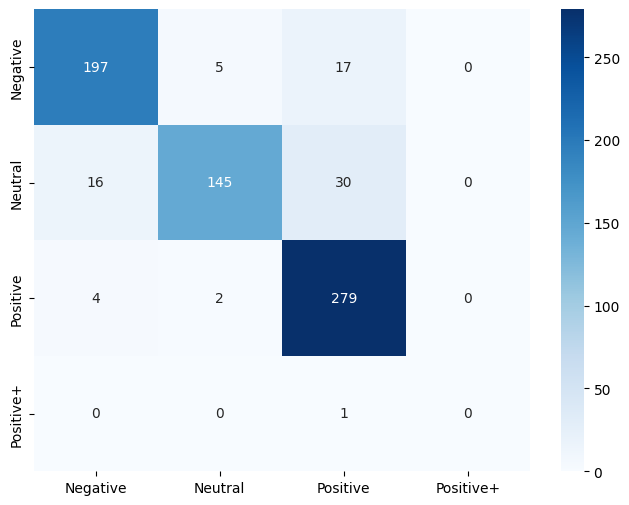

In [61]:
plt.figure(figsize=(8,6))
sns.heatmap(
    con,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative","Neutral", "Positive","Positive+"],
    yticklabels=["Negative","Neutral", "Positive","Positive+"]
)
plt.Xlabels="predicted",
plt.ylabels="actual"
plt.title="NLP Predicted vs actual"
plt.show()


In [67]:
text=input("Enter your text:")
text_vec=vectorizer.transform([text])
prediction= model.predict(text_vec)
print("Sentiment:",prediction[0])

Enter your text:I love spending time with my family
Sentiment: positive
